In [ ]:
%pip install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier Excel
df = pd.read_excel('TP1 data 60201 W2026.xlsx')

# Afficher les premières lignes pour comprendre la structure
print("Colonnes disponibles:")
print(df.columns.tolist())
print("\nPremières lignes:")
print(df.head())


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Colonnes disponibles:
['Date', 'BETA0', 'BETA1', 'BETA2', 'BETA3', 'TAU1', 'TAU2']

Premières lignes:
        Date     BETA0     BETA1     BETA2     BETA3      TAU1      TAU2
0 2019-08-07  3.287166 -1.061883 -2.235671 -3.534955  1.619909  6.371644
1 2019-08-14  2.941188 -0.686072 -1.787607 -3.453069  1.274656  5.984395
2 2019-08-21  3.044167 -0.890212 -1.782100 -3.479495  1.522583  6.119485
3 2019-08-28  2.787686 -0.606353 -1.654560 -3.224743  1.484809  5.641838
4 2019-09-04  2.822265 -0.612726 -2.100801 -3.021262  1.592631  5.826534


In [2]:
# Définir la fonction Nelson-Siegel-Svensson
def nelson_siegel_svensson(tau, beta0, beta1, beta2, beta3, lambda1, lambda2):
    """
    Calcule le taux zéro-coupon selon le modèle Nelson-Siegel-Svensson
    
    tau: maturité en années
    beta0, beta1, beta2, beta3: paramètres du modèle
    lambda1, lambda2: facteurs de décroissance
    """
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-lambda1 * tau)) / (lambda1 * tau))
    term3 = beta2 * (((1 - np.exp(-lambda1 * tau)) / (lambda1 * tau)) - np.exp(-lambda1 * tau))
    term4 = beta3 * (((1 - np.exp(-lambda2 * tau)) / (lambda2 * tau)) - np.exp(-lambda2 * tau))
    
    return term1 + term2 + term3 + term4

In [ ]:
# Maturités à calculer (en années)
maturities = {
    '3 mois': 0.25,
    '6 mois': 0.5,
    '1 an': 1,
    '3 ans': 3,
    '5 ans': 5,
    '10 ans': 10,
    '30 ans': 30
}

# Calculer les taux pour chaque maturité
# Supposons que les colonnes contiennent BETA0, BETA1, BETA2, BETA3, TAU1, TAU2
# Adapter les noms de colonnes selon votre fichier

for maturity_name, tau in maturities.items():
    df[f'taux_{maturity_name}'] = nelson_siegel_svensson(
        tau, 
        df['BETA0'], 
        df['BETA1'], 
        df['BETA2'], 
        df['BETA3'], 
        df['TAU1'], 
        df['TAU2']
    )

# Afficher un aperçu
print("\nTaux calculés pour les premières dates:")
print(df[['Date'] + [f'taux_{m}' for m in maturities.keys()]].head())
display(df[['Date'] + [f'taux_{m}' for m in maturities.keys()]].head())


Taux calculés pour les premières dates:
        Date  taux_3 mois  taux_6 mois  taux_1 an  taux_3 ans  taux_5 ans  \
0 2019-08-07     1.017626     1.104146   1.549085    2.446280    2.769881   
1 2019-08-14     1.105172     1.134190   1.475811    2.155134    2.441365   
2 2019-08-21     1.011256     1.085121   1.500997    2.294171    2.580479   
3 2019-08-28     1.099010     1.096282   1.426670    2.114735    2.370001   
4 2019-09-04     1.107845     1.082173   1.384182    2.103940    2.378648   

   taux_10 ans  taux_30 ans  
0     3.028123     3.200818  
1     2.689426     2.857265  
2     2.811796     2.966710  
3     2.578260     2.717877  
4     2.600032     2.748187  


In [48]:
# Vérification des unités des taux
rate_columns = [f'taux_{m}' for m in maturities.keys()]

# Construct NSS short rate 
df['taux_court_NSS'] = df['BETA0'] + df['BETA1']
rate_columns.append('taux_court_NSS')

# Check if rates look like percentages
mean_rate = df[rate_columns].mean().mean()
print(f"\nVérification des unités des taux:")
print(f"Moyenne des taux: {mean_rate:.4f}")

if mean_rate > 1:
    print("→ Les taux sont en pourcentage. Conversion en forme décimale...")
    df[rate_columns] = df[rate_columns] / 100
    print("✓ Conversion effectuée: tous les taux sont maintenant en forme décimale")
    print(f"  Nouvelle moyenne: {df[rate_columns].mean().mean():.6f}")
else:
    print("Les taux sont déjà en forme décimale ")


display(df[rate_columns].head())


Vérification des unités des taux:
Moyenne des taux: 0.3769
Les taux sont déjà en forme décimale 


,taux_3 mois,taux_6 mois,taux_1 an,taux_3 ans,taux_5 ans,taux_10 ans,taux_30 ans,taux_court_NSS
0,0.010176,0.011041,0.015491,0.024463,0.027699,0.030281,0.032008,2.225283
1,0.011052,0.011342,0.014758,0.021551,0.024414,0.026894,0.028573,2.255115
2,0.010113,0.010851,0.015010,0.022942,0.025805,0.028118,0.029667,2.153955
3,0.010990,0.010963,0.014267,0.021147,0.023700,0.025783,0.027179,2.181334
4,0.011078,0.010822,0.013842,0.021039,0.023786,0.026000,0.027482,2.209539


In [49]:
# Calculer les statistiques descriptives
stats = []

for maturity_name in maturities.keys():
    col_name = f'taux_{maturity_name}'
    stats.append({
        'Maturité': maturity_name,
        'Moyenne': df[col_name].mean(),
        'Écart-type': df[col_name].std(),
        'Q1 (25%)': df[col_name].quantile(0.25),
        'Q2 (50% - Médiane)': df[col_name].quantile(0.50),
        'Q3 (75%)': df[col_name].quantile(0.75)
    })

# Créer le tableau de statistiques
stats_df = pd.DataFrame(stats)
stats_df = stats_df.set_index('Maturité')

# Afficher le tableau formaté
print("\nTableau de statistiques descriptives:")
display((stats_df * 100).round(4))


Tableau de statistiques descriptives:


,Moyenne,Écart-type,Q1 (25%),Q2 (50% - Médiane),Q3 (75%)
Maturité,,,,,
3 mois,2.8768,2.9200,-0.2081,3.0748,5.7437
6 mois,2.4441,2.2149,0.3306,1.6446,4.5598
1 an,2.3626,1.6823,0.7902,2.0881,3.9579
3 ans,2.5052,1.4359,1.5608,2.5941,3.7038
5 ans,2.5494,1.4604,1.8279,2.5244,3.5701
10 ans,2.5816,1.4968,1.9846,2.5204,3.5017
30 ans,2.6051,1.5381,1.9599,2.5866,3.5178


## Question 2: Modèle CIR avec filtre de Kalman



In [10]:
from scipy.optimize import minimize
from scipy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

# Fonction pour calculer le prix zéro-coupon dans le modèle CIR
def cir_bond_price(r, tau, kappa, theta, sigma):
    """
    Prix d'une obligation zéro-coupon dans le modèle CIR
    r: taux court actuel
    tau: maturité
    kappa, theta, sigma: paramètres du modèle CIR
    """
    h = np.sqrt(kappa**2 + 2*sigma**2)
    A = ((2*h*np.exp((kappa+h)*tau/2)) / (2*h + (kappa+h)*(np.exp(tau*h)-1)))**(2*kappa*theta/sigma**2)
    B = (2*(np.exp(tau*h)-1)) / (2*h + (kappa+h)*(np.exp(tau*h)-1))
    return A * np.exp(-B*r)

def cir_yield(r, tau, kappa, theta, sigma):
    """
    Taux zéro-coupon dans le modèle CIR
    """
    P = cir_bond_price(r, tau, kappa, theta, sigma)
    return -np.log(P) / tau

In [13]:
class KalmanFilterCIR:
    """
    Filtre de Kalman pour le modèle CIR avec variance d'erreur de mesure par maturité
    """
    def __init__(self, maturities):
        self.maturities = np.array(maturities)
        
    def kalman_filter(self, yields, kappa, theta, sigma, sigma_epsilon_vec, dt=1/52):
        """
        Applique le filtre de Kalman
        yields: matrice (T x n) des taux observés
        sigma_epsilon_vec: vecteur (n,) des écarts-types d'erreur de mesure par maturité
        dt: pas de temps (hebdomadaire = 1/52)
        """
        T, n = yields.shape
        
        # Vérifier que sigma_epsilon_vec a la bonne dimension
        if len(sigma_epsilon_vec) != n:
            raise ValueError(f"sigma_epsilon_vec doit avoir {n} éléments, un par maturité")
        
        # Initialisation
        r_filtered = np.zeros(T)
        r_predicted = np.zeros(T)
        P_filtered = np.zeros(T)
        P_predicted = np.zeros(T)
        
        # Valeurs initiales
        r_filtered[0] = theta  
        P_filtered[0] = theta * sigma**2 / (2 * kappa)  
        # Matrice de covariance des erreurs de mesure (diagonale)
        R = np.diag(sigma_epsilon_vec**2)
        
        log_likelihood = 0
        innovations = np.zeros((T, n))
        
        for t in range(1, T):
            # Prediction
            r_predicted[t] = r_filtered[t-1] + kappa * (theta - r_filtered[t-1]) * dt
            
            F = 1 - kappa * dt 
            
            Q = (sigma**2) * max(r_filtered[t-1], 1e-12) * dt  

            P_predicted[t] = (F**2) * P_filtered[t-1] + Q
            
            # Taux prédits pour chaque maturité 
            y_predicted = np.array([cir_yield(r_predicted[t], tau, kappa, theta, sigma) 
                                   for tau in self.maturities])
            
            # Erreur de mesure = taux observés - taux prédits
    
            innovation = yields[t, :] - y_predicted
            innovations[t, :] = innovation
            
            # Jacobien de la fonction d'observation (approximation numérique)
            H = np.zeros(n)
            eps = 1e-6
            for i, tau in enumerate(self.maturities):
                y_plus = cir_yield(r_predicted[t] + eps, tau, kappa, theta, sigma)
                y_minus = cir_yield(r_predicted[t] - eps, tau, kappa, theta, sigma)
                H[i] = (y_plus - y_minus) / (2 * eps)
            
            # Matrice de covariance de l'innovation
            S = H.reshape(-1, 1) @ np.array([[P_predicted[t]]]) @ H.reshape(1, -1) + R
            
            # Check if S is positive definite
            sign, logdet = np.linalg.slogdet(S)
            if sign <= 0 or not np.isfinite(logdet):
                return r_filtered, -1e12, innovations 
            
            # Gain de Kalman 
            K = P_predicted[t] * (H @ np.linalg.solve(S, np.eye(n)))
            
            r_filtered[t] = r_predicted[t] + K @ innovation
            P_filtered[t] = (1 - K @ H) * P_predicted[t]
            
            # Log-vraisemblance 
            quad = innovation.T @ np.linalg.solve(S, innovation)
            log_likelihood += -0.5 * (n * np.log(2*np.pi) + logdet + quad)
        
        return r_filtered, log_likelihood, innovations

In [16]:
# Préparer les données pour l'estimation
tau_list = [0.25, 0.5, 1, 3, 5, 10, 30]  # maturités en années
yield_cols = [f'taux_{m}' for m in maturities.keys()]

# Convertir les taux en matrice numpy
yields_matrix = df[yield_cols].values

# Vérifier les données
print(f"Forme de la matrice des taux: {yields_matrix.shape}")
print(f"Période: {df['Date'].min()} à {df['Date'].max()}")
print(f"Nombre d'observations: {len(yields_matrix)}")

Forme de la matrice des taux: (338, 7)
Période: 2019-08-07 00:00:00 à 2026-01-21 00:00:00
Nombre d'observations: 338


In [22]:
# Vérification et normalisation des unités (% vs décimal) avant estimation
avg_level = np.mean(yields_matrix)
min_level = np.min(yields_matrix)
max_level = np.max(yields_matrix)

print("\n" + "-"*80)
print("VÉRIFICATION DES UNITÉS DES TAUX")
print("-"*80)
print(f"Moyenne des taux: {avg_level:.4f}")
print(f"Min: {min_level:.4f}, Max: {max_level:.4f}")

# Conversion en décimales si nécessaire
if avg_level > 1:
    yields_matrix = yields_matrix / 100
    avg_level_new = np.mean(yields_matrix)
    print(f"  Nouvelle moyenne: {avg_level_new:.6f}")
    print(f"  Nouveau min: {np.min(yields_matrix):.6f}, max: {np.max(yields_matrix):.6f}")
else:
    print("Les taux sont déjà en forme décimale")

print("-"*80 + "\n")


--------------------------------------------------------------------------------
VÉRIFICATION DES UNITÉS DES TAUX
--------------------------------------------------------------------------------
Moyenne des taux: 0.0256
Min: -0.0618, Max: 0.0787
Les taux sont déjà en forme décimale
--------------------------------------------------------------------------------



In [23]:
# Fonction objectif pour l'optimisation
def negative_log_likelihood(params, yields, maturities):
    """
    Fonction à minimiser (log-vraisemblance négative)
    params = [kappa, theta, sigma, sigma_eps_1, ..., sigma_eps_n]
    où n = nombre de maturités (7)
    """
    n_maturities = len(maturities)
    
    # Extraire les paramètres
    kappa = params[0]
    theta = params[1]
    sigma = params[2]
    sigma_epsilon_vec = np.array(params[3:3+n_maturities])  

    # Contraintes pour assurer la validité des paramètres
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e12
    
    # Tous les sigma_epsilon doivent être positifs
    if np.any(sigma_epsilon_vec <= 0):
        return 1e12
    
    # Condition de Feller pour le modèle CIR
    if 2*kappa*theta < sigma**2:
        return 1e12
    
    try:
        kf = KalmanFilterCIR(maturities)
        _, log_lik, _ = kf.kalman_filter(yields, kappa, theta, sigma, sigma_epsilon_vec)
        
        # Vérifier que la log-vraisemblance est finie (pas NaN ou Inf)
        if not np.isfinite(log_lik):
            return 1e12
        
        return -log_lik
    except Exception:
        return 1e12



In [52]:
# Valeurs initiales des paramètres
n_maturities = len(tau_list)
initial_params = np.array([0.5, 0.03, 0.05] + [0.005]*n_maturities)

print(f"Vecteur de paramètres initiaux ({len(initial_params)} paramètres):")
print(f"  κ (kappa)     = {initial_params[0]}")
print(f"  θ (theta)     = {initial_params[1]}")
print(f"  σ (sigma)     = {initial_params[2]}")
for i, mat_name in enumerate(maturities.keys()):
    print(f"  σ_ε ({mat_name:6s}) = {initial_params[3+i]}")

# Bounds 
bounds = (
    [(1e-6, 5.0),   
     (1e-6, 0.20),  
     (1e-6, 1.0)]   
    + [(1e-6, 0.10)] * n_maturities  
)

print(f"\nBornes des paramètres:")
print(f"  κ (kappa):     [{bounds[0][0]}, {bounds[0][1]}]")
print(f"  θ (theta):     [{bounds[1][0]}, {bounds[1][1]}]")
print(f"  σ (sigma):     [{bounds[2][0]}, {bounds[2][1]}]")
print(f"  σ_ε (chaque):  [{bounds[3][0]}, {bounds[3][1]}]")

# Optimisation avec L-BFGS-B 
result = minimize(
    negative_log_likelihood,
    initial_params,
    args=(yields_matrix, tau_list),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 5000, 'disp': True}
)

# Paramètres estimés
kappa_est = result.x[0]
theta_est = result.x[1]
sigma_est = result.x[2]
sigma_eps_vec_est = result.x[3:3+n_maturities]
log_lik_max = -result.fun

print("\n" + "-"*80)
print("RÉSULTATS DE L'ESTIMATION")
print("-"*80)
print(f"κ (kappa):        {kappa_est:.6f}")
print(f"θ (theta):        {theta_est:.6f}")
print(f"σ (sigma):        {sigma_est:.6f}")
print(f"\nVariances d'erreur de mesure par maturité:")
for i, mat_name in enumerate(maturities.keys()):
    print(f"  σ_ε ({mat_name:6s}): {sigma_eps_vec_est[i]:.6f}")

# Affichage haute précision pour vérifier si les paramètres bougent
print(f"\n[HAUTE PRÉCISION] Variances d'erreur de mesure:")
for i, mat_name in enumerate(maturities.keys()):
    print(f"  σ_ε ({mat_name:6s}): {sigma_eps_vec_est[i]:.12e}")

print(f"\nLog-vraisemblance: {log_lik_max:.2f}")
print("-"*80)


Vecteur de paramètres initiaux (10 paramètres):
  κ (kappa)     = 0.5
  θ (theta)     = 0.03
  σ (sigma)     = 0.05
  σ_ε (3 mois) = 0.005
  σ_ε (6 mois) = 0.005
  σ_ε (1 an  ) = 0.005
  σ_ε (3 ans ) = 0.005
  σ_ε (5 ans ) = 0.005
  σ_ε (10 ans) = 0.005
  σ_ε (30 ans) = 0.005

Bornes des paramètres:
  κ (kappa):     [1e-06, 5.0]
  θ (theta):     [1e-06, 0.2]
  σ (sigma):     [1e-06, 1.0]
  σ_ε (chaque):  [1e-06, 0.1]

--------------------------------------------------------------------------------
RÉSULTATS DE L'ESTIMATION
--------------------------------------------------------------------------------
κ (kappa):        1.229424
θ (theta):        0.024350
σ (sigma):        0.243859

Variances d'erreur de mesure par maturité:
  σ_ε (3 mois): 0.011562
  σ_ε (6 mois): 0.007707
  σ_ε (1 an  ): 0.009758
  σ_ε (3 ans ): 0.013480
  σ_ε (5 ans ): 0.014605
  σ_ε (10 ans): 0.015516
  σ_ε (30 ans): 0.016110

[HAUTE PRÉCISION] Variances d'erreur de mesure:
  σ_ε (3 mois): 1.156162755479e-02
  σ_ε 

In [54]:
# Calcul des erreurs standard 
def compute_hessian(func, params, args, eps=1e-5):
    """
    Calcule la Hessienne numérique
    """
    n = len(params)
    hessian = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            params_pp = params.copy()
            params_pm = params.copy()
            params_mp = params.copy()
            params_mm = params.copy()
            
            params_pp[i] += eps
            params_pp[j] += eps
            
            params_pm[i] += eps
            params_pm[j] -= eps
            
            params_mp[i] -= eps
            params_mp[j] += eps
            
            params_mm[i] -= eps
            params_mm[j] -= eps
            
            f_pp = func(params_pp, *args)
            f_pm = func(params_pm, *args)
            f_mp = func(params_mp, *args)
            f_mm = func(params_mm, *args)
            
            hessian[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * eps**2)
    
    return hessian

print("Calcul des erreurs standard...")
hessian = compute_hessian(negative_log_likelihood, result.x, (yields_matrix, tau_list))

# Matrice de covariance = inverse de la Hessienne
try:
    cov_matrix = inv(hessian)
    std_errors = np.sqrt(np.diag(cov_matrix))
    print("Erreurs standard calculées avec succès.\n")
except:
    print("Attention: la Hessienne n'est pas inversible. Erreurs standard approximatives.\n")
    std_errors = np.abs(result.x) * 0.1  

Calcul des erreurs standard...
Erreurs standard calculées avec succès.



In [53]:
# Tableau 1: Paramètres estimés
param_names = ['κ (kappa)', 'θ (theta)', 'σ (sigma)']
for mat_name in maturities.keys():
    param_names.append(f'σ_ε ({mat_name})')

params_table = pd.DataFrame({
    'Paramètre': param_names,
    'Estimation': result.x,
    'Erreur Standard': std_errors,
    'T-stat': result.x / std_errors
})

print("\n" + "-"*80)
print("TABLEAU 1: PARAMÈTRES ESTIMÉS DU MODÈLE CIR")

display(params_table)
print(f"\nLog-vraisemblance maximisée: {log_lik_max:.4f}")
print(f"Nombre d'observations: {len(yields_matrix)}")
print(f"Nombre de paramètres: {len(result.x)}")
print("-"*80)



--------------------------------------------------------------------------------
TABLEAU 1: PARAMÈTRES ESTIMÉS DU MODÈLE CIR


,Paramètre,Estimation,Erreur Standard,T-stat
0,κ (kappa),1.229424,0.082980,14.815899
1,θ (theta),0.024350,0.000530,45.945759
2,σ (sigma),0.243859,0.018592,13.116433
3,σ_ε (3 mois),0.011562,0.000568,20.368724
4,σ_ε (6 mois),0.007707,0.000347,22.229666
5,σ_ε (1 an),0.009758,0.000424,23.017186
6,σ_ε (3 ans),0.013480,0.000516,26.130126
7,σ_ε (5 ans),0.014605,0.000566,25.793364
8,σ_ε (10 ans),0.015516,0.000620,25.032691
9,σ_ε (30 ans),0.016110,0.000655,24.578597



Log-vraisemblance maximisée: 6923.7277
Nombre d'observations: 338
Nombre de paramètres: 10
--------------------------------------------------------------------------------


In [51]:
# Calculer les erreurs de mesure pour chaque maturité

kf = KalmanFilterCIR(tau_list)
r_filtered, _, innovations = kf.kalman_filter(yields_matrix, kappa_est, theta_est, 
                                               sigma_est, sigma_eps_vec_est)

# Tableau 2: Statistiques des erreurs de mesure par maturité
measurement_errors = []
maturity_names = list(maturities.keys())

for i, mat_name in enumerate(maturity_names):
    errors = innovations[1:, i]
    measurement_errors.append({
        'Maturité': mat_name,
        'Moyenne des erreurs': np.mean(errors),
        'Variance des erreurs': np.var(errors),
        'Variance estimée (σ²)': sigma_eps_vec_est[i]**2,
        'Écart-type': np.std(errors),
        'RMSE': np.sqrt(np.mean(errors**2))
    })

errors_table = pd.DataFrame(measurement_errors)
errors_table = errors_table.set_index('Maturité')


print("TABLEAU 2: ERREURS DE MESURE PAR MATURITÉ")
display(errors_table.round(6))

TABLEAU 2: ERREURS DE MESURE PAR MATURITÉ


,Moyenne des erreurs,Variance des erreurs,Variance estimée (σ²),Écart-type,RMSE
Maturité,,,,,
3 mois,0.002272,0.000175,0.000134,0.013217,0.013411
6 mois,-0.001747,0.000099,0.000059,0.009935,0.010087
1 an,-0.002066,0.000122,0.000095,0.011059,0.011251
3 ans,0.000319,0.000200,0.000182,0.014130,0.014134
5 ans,0.001080,0.000219,0.000213,0.014808,0.014847
10 ans,0.001654,0.000231,0.000241,0.015212,0.015302
30 ans,0.002058,0.000240,0.000260,0.015497,0.015633


## Question 3: Comparaison des trajectoires du taux court

Comparaison entre :
- Le taux court estimé par le filtre de Kalman (modèle CIR)
- Le taux instantané du modèle Nelson-Siegel-Svensson (limite quand τ → 0)

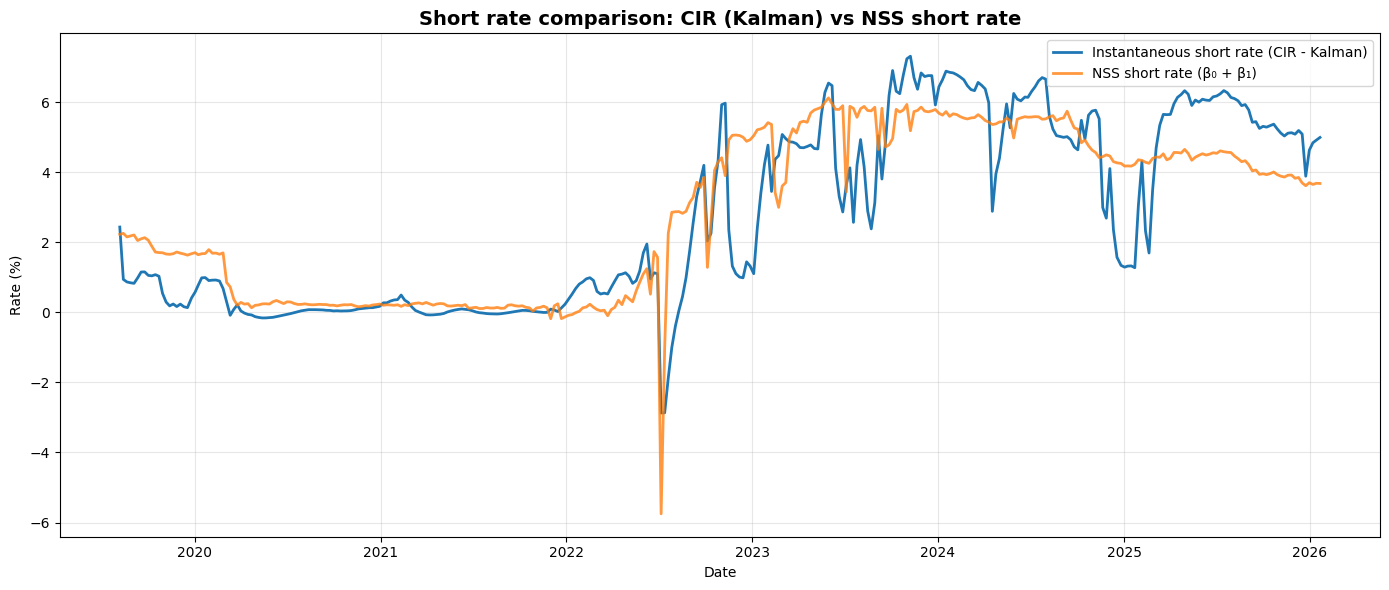

In [58]:
# Question 3 : Comparison of CIR filtered short rate vs NSS short rate

# Rebuild taux_court_NSS if this column is missing
if "taux_court_NSS" not in df.columns:
    if {"BETA0", "BETA1"}.issubset(df.columns):
        df["taux_court_NSS"] = df["BETA0"] + df["BETA1"]
    else:
        raise KeyError("Missing 'taux_court_NSS' and source columns 'BETA0'/'BETA1'.")

# Convertir le taux CIR en pourcentage
r_filtered_pct = r_filtered * 100

# Plot comparison (en %)
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], r_filtered_pct,
         label="Instantaneous short rate (CIR - Kalman)",
         linewidth=2)

plt.plot(df["Date"], df["taux_court_NSS"],
         label="NSS short rate (β₀ + β₁)",
         linewidth=2, alpha=0.8)

plt.title("Short rate comparison: CIR (Kalman) vs NSS short rate",
          fontsize=14, fontweight="bold")

plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
# Utiliser le taux instantané du modèle Nelson-Siegel-Svensson
df['r_NSS'] = df['taux_court_NSS']

print(f"\nTaux instantané NSS pour {len(df)} observations")
print(f"Moyenne: {df['r_NSS'].mean():.6f} ({df['r_NSS'].mean()*100:.4f}%)")
print(f"Min: {df['r_NSS'].min():.6f}, Max: {df['r_NSS'].max():.6f}")


Taux instantané NSS pour 338 observations
Moyenne: 2.836042 (283.6042%)
Min: -5.752362, Max: 6.122489


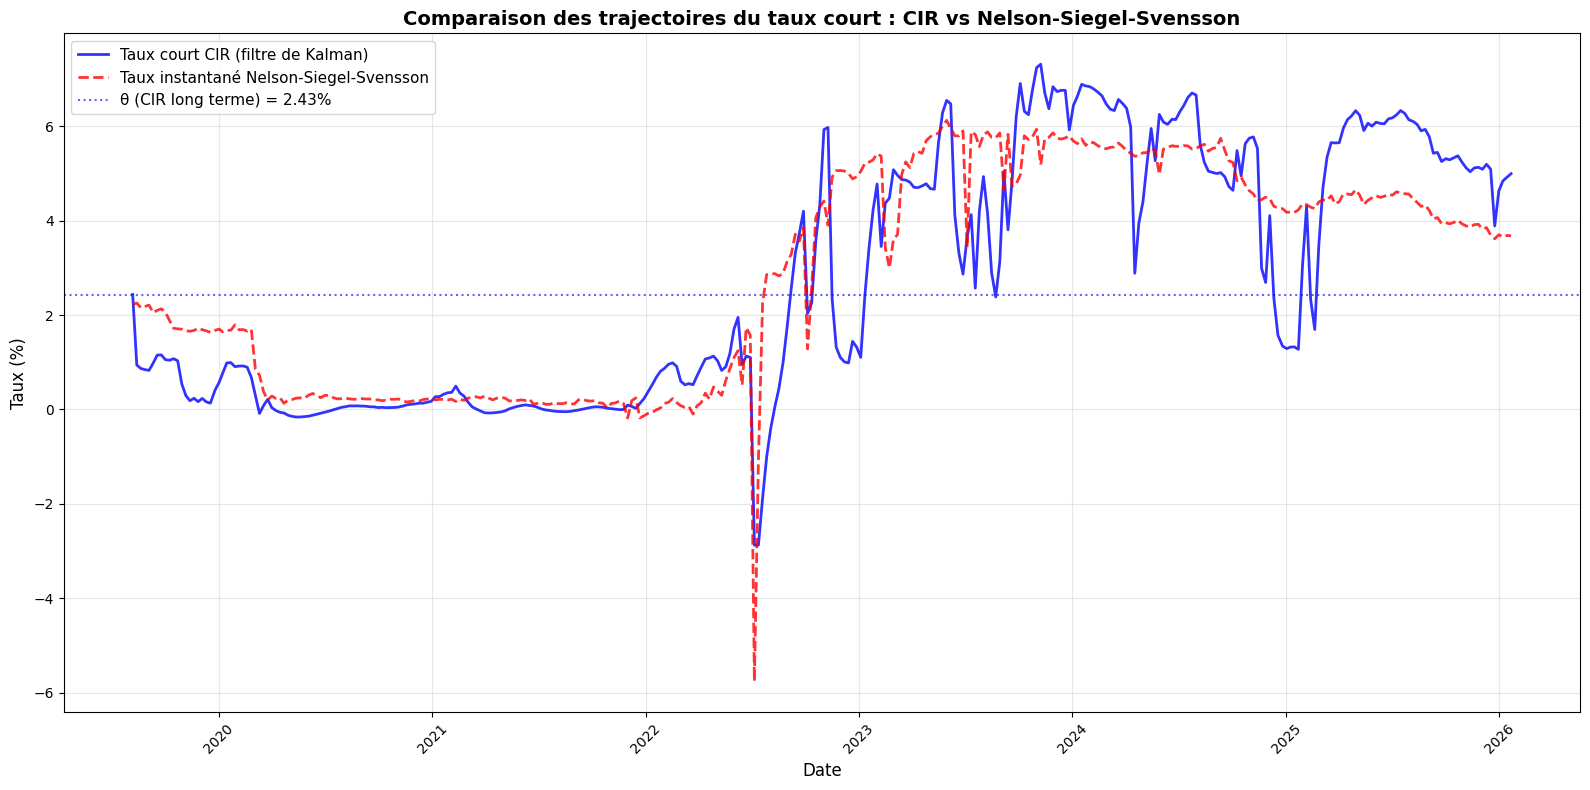


Période d'analyse : 2019-08-07 00:00:00 à 2026-01-21 00:00:00


In [60]:
# Ajouter le taux court CIR au dataframe pour comparaison
df['r_CIR'] = r_filtered

# Conversion en pourcentage pour cohérence d'échelle
df['r_CIR_pct'] = df['r_CIR'] * 100
theta_pct = theta_est * 100

# Tracer les deux trajectoires
plt.figure(figsize=(16, 8))

plt.plot(df['Date'], df['r_CIR_pct'],
         label='Taux court CIR (filtre de Kalman)',
         linewidth=2, color='blue', alpha=0.8)

plt.plot(df['Date'], df['r_NSS'],
         label='Taux instantané Nelson-Siegel-Svensson',
         linewidth=2, color='red', alpha=0.8, linestyle='--')

# Ajouter le niveau de long terme du CIR
plt.axhline(y=theta_pct,
            color='blue',
            linestyle=':',
            alpha=0.6,
            label=f'θ (CIR long terme) = {theta_pct:.2f}%')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Taux (%)', fontsize=12)
plt.title('Comparaison des trajectoires du taux court : CIR vs Nelson-Siegel-Svensson',
          fontsize=14, fontweight='bold')

plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nPériode d'analyse : {df['Date'].min()} à {df['Date'].max()}")

In [61]:
# Statistiques de comparaison entre les deux trajectoires

print("="*80)
print("ANALYSE COMPARATIVE DES DEUX TRAJECTOIRES")
print("="*80)

# 1. Statistiques descriptives
print("\n1. STATISTIQUES DESCRIPTIVES")
print("-" * 80)
comparison_stats = pd.DataFrame({
    'Modèle': ['CIR (Kalman)', 'NSS (Instantané)'],
    'Moyenne': [df['r_CIR'].mean(), df['r_NSS'].mean()],
    'Écart-type': [df['r_CIR'].std(), df['r_NSS'].std()],
    'Minimum': [df['r_CIR'].min(), df['r_NSS'].min()],
    'Maximum': [df['r_CIR'].max(), df['r_NSS'].max()],
    'Médiane': [df['r_CIR'].median(), df['r_NSS'].median()]
})
print(comparison_stats.to_string(index=False))

# 2. Corrélation et différences
print("\n2. RELATION ENTRE LES DEUX SÉRIES")
print("-" * 80)
correlation = df['r_CIR'].corr(df['r_NSS'])
print(f"Corrélation: {correlation:.4f}")

# Calculer les différences
df['diff'] = df['r_CIR'] - df['r_NSS']
print(f"\nDifférence moyenne (CIR - NSS): {df['diff'].mean():.6f}")
print(f"Écart-type de la différence: {df['diff'].std():.6f}")
print(f"MAE (Mean Absolute Error): {np.abs(df['diff']).mean():.6f}")
print(f"RMSE: {np.sqrt(np.mean(df['diff']**2)):.6f}")

# 3. Test de normalité sur les différences
from scipy import stats
_, p_value_shapiro = stats.shapiro(df['diff'].dropna())
print(f"\nTest de Shapiro-Wilk sur les différences:")
print(f"   p-value = {p_value_shapiro:.4f}")
if p_value_shapiro > 0.05:
    print(f"   → Les différences suivent une loi normale (p > 0.05)")
else:
    print(f"   → Les différences ne suivent pas une loi normale (p < 0.05)")

# 4. Périodes de divergence maximale
print("\n3. PÉRIODES DE DIVERGENCE MAXIMALE")
print("-" * 80)
df_sorted = df.sort_values('diff', ascending=False)
print("\nTop 5 des écarts positifs (CIR > NSS):")
print(df_sorted[['Date', 'r_CIR', 'r_NSS', 'diff']].head().to_string(index=False))

print("\nTop 5 des écarts négatifs (CIR < NSS):")
print(df_sorted[['Date', 'r_CIR', 'r_NSS', 'diff']].tail().to_string(index=False))

print("\n" + "="*80)

ANALYSE COMPARATIVE DES DEUX TRAJECTOIRES

1. STATISTIQUES DESCRIPTIVES
--------------------------------------------------------------------------------
          Modèle  Moyenne  Écart-type   Minimum  Maximum  Médiane
    CIR (Kalman) 0.027051    0.026196 -0.028738 0.073126 0.015070
NSS (Instantané) 2.836042    2.305049 -5.752362 6.122489 3.610985

2. RELATION ENTRE LES DEUX SÉRIES
--------------------------------------------------------------------------------
Corrélation: 0.8708

Différence moyenne (CIR - NSS): -2.808991
Écart-type de la différence: 2.282274
MAE (Mean Absolute Error): 2.853214
RMSE: 3.617153

Test de Shapiro-Wilk sur les différences:
   p-value = 0.0000
   → Les différences ne suivent pas une loi normale (p < 0.05)

3. PÉRIODES DE DIVERGENCE MAXIMALE
--------------------------------------------------------------------------------

Top 5 des écarts positifs (CIR > NSS):
      Date     r_CIR     r_NSS     diff
2022-07-06 -0.028738 -5.752362 5.723624
2022-07-13 -0.0286